# Employee Attrition Prediction — Hybrid Residual-Ensemble (TabNet + LightGBM)

In [1]:
!pip install -q pytorch-tabnet lightgbm imbalanced-learn  # install libs not in base Colab/Kaggle image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.9 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings('ignore')  # silence sklearn/lightgbm/tabnet deprecation noise
import time  # for simple wall-clock timing of each model
from tqdm.auto import tqdm  # progress bars for CV loops
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE  # class-imbalance oversampling
import lightgbm as lgb
import torch
from pytorch_tabnet.tab_model import TabNetClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)  # reproducible TabNet init/training
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # use GPU if available
print(f"device: {DEVICE}")
if DEVICE == 'cuda':
    print(torch.cuda.get_device_name(0))


device: cuda
Tesla T4


## I. Load Data

### I.1 Read the CSV

In [3]:
import os

CSV_PATH = '/content/WA_Fn-UseC_-HR-Employee-Attrition.csv'  # Kaggle IBM HR Attrition dataset
df = pd.read_csv(CSV_PATH)  # load raw dataset
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### I.2 Data Types & Info

In [4]:
df.info()  # dtypes + non-null counts per column


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### I.3 Missing Values & Duplicates

In [5]:
print("missing values:", df.isnull().sum().sum())
print("duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)  # remove exact duplicate rows
print("shape after dropping duplicates:", df.shape)


missing values: 0
duplicate rows: 0
shape after dropping duplicates: (1470, 35)


## II. Exploratory Data Analysis

### II.1 Target Distribution

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.88
Yes    16.12
Name: count, dtype: float64


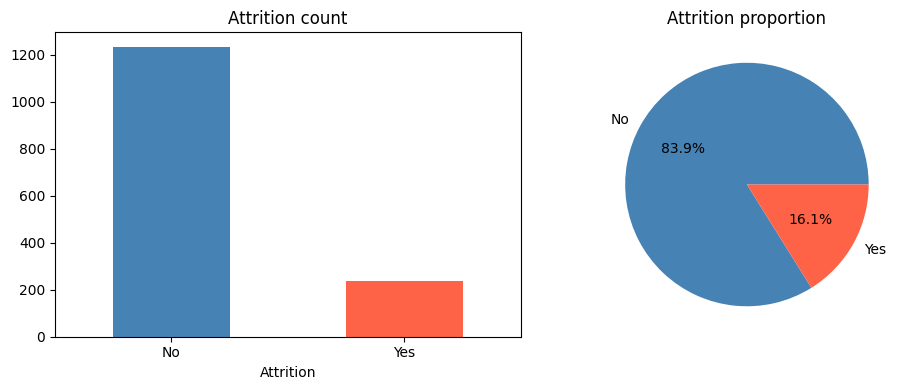

In [6]:
attrition_counts = df['Attrition'].value_counts()  # raw Yes/No counts
print(attrition_counts)
print((attrition_counts / len(df) * 100).round(2))  # class % split

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
attrition_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])  # bar view
axes[0].set_title('Attrition count')
axes[0].tick_params(axis='x', rotation=0)
axes[1].pie(attrition_counts, labels=attrition_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'])  # proportion view
axes[1].set_title('Attrition proportion')
plt.tight_layout()
plt.show()

### II.2 Descriptive Statistics

In [7]:
df.describe().T  # summary stats for all numeric columns


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


### II.3 Skewness Check

In [8]:
# continuous numeric features used throughout EDA/cleaning
continuous_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
                   'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
                   'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
                   'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
                   'YearsWithCurrManager']

skew_table = df[continuous_cols].skew().sort_values(ascending=False)  # >1 or <-1 = skewed
print("Skewness (continuous features):")
print(skew_table.round(2))

Skewness (continuous features):
YearsSinceLastPromotion    1.98
YearsAtCompany             1.76
MonthlyIncome              1.37
TotalWorkingYears          1.12
NumCompaniesWorked         1.03
DistanceFromHome           0.96
YearsInCurrentRole         0.92
YearsWithCurrManager       0.83
PercentSalaryHike          0.82
TrainingTimesLastYear      0.55
Age                        0.41
MonthlyRate                0.02
DailyRate                 -0.00
HourlyRate                -0.03
dtype: float64


### II.4 Outlier Boxplots

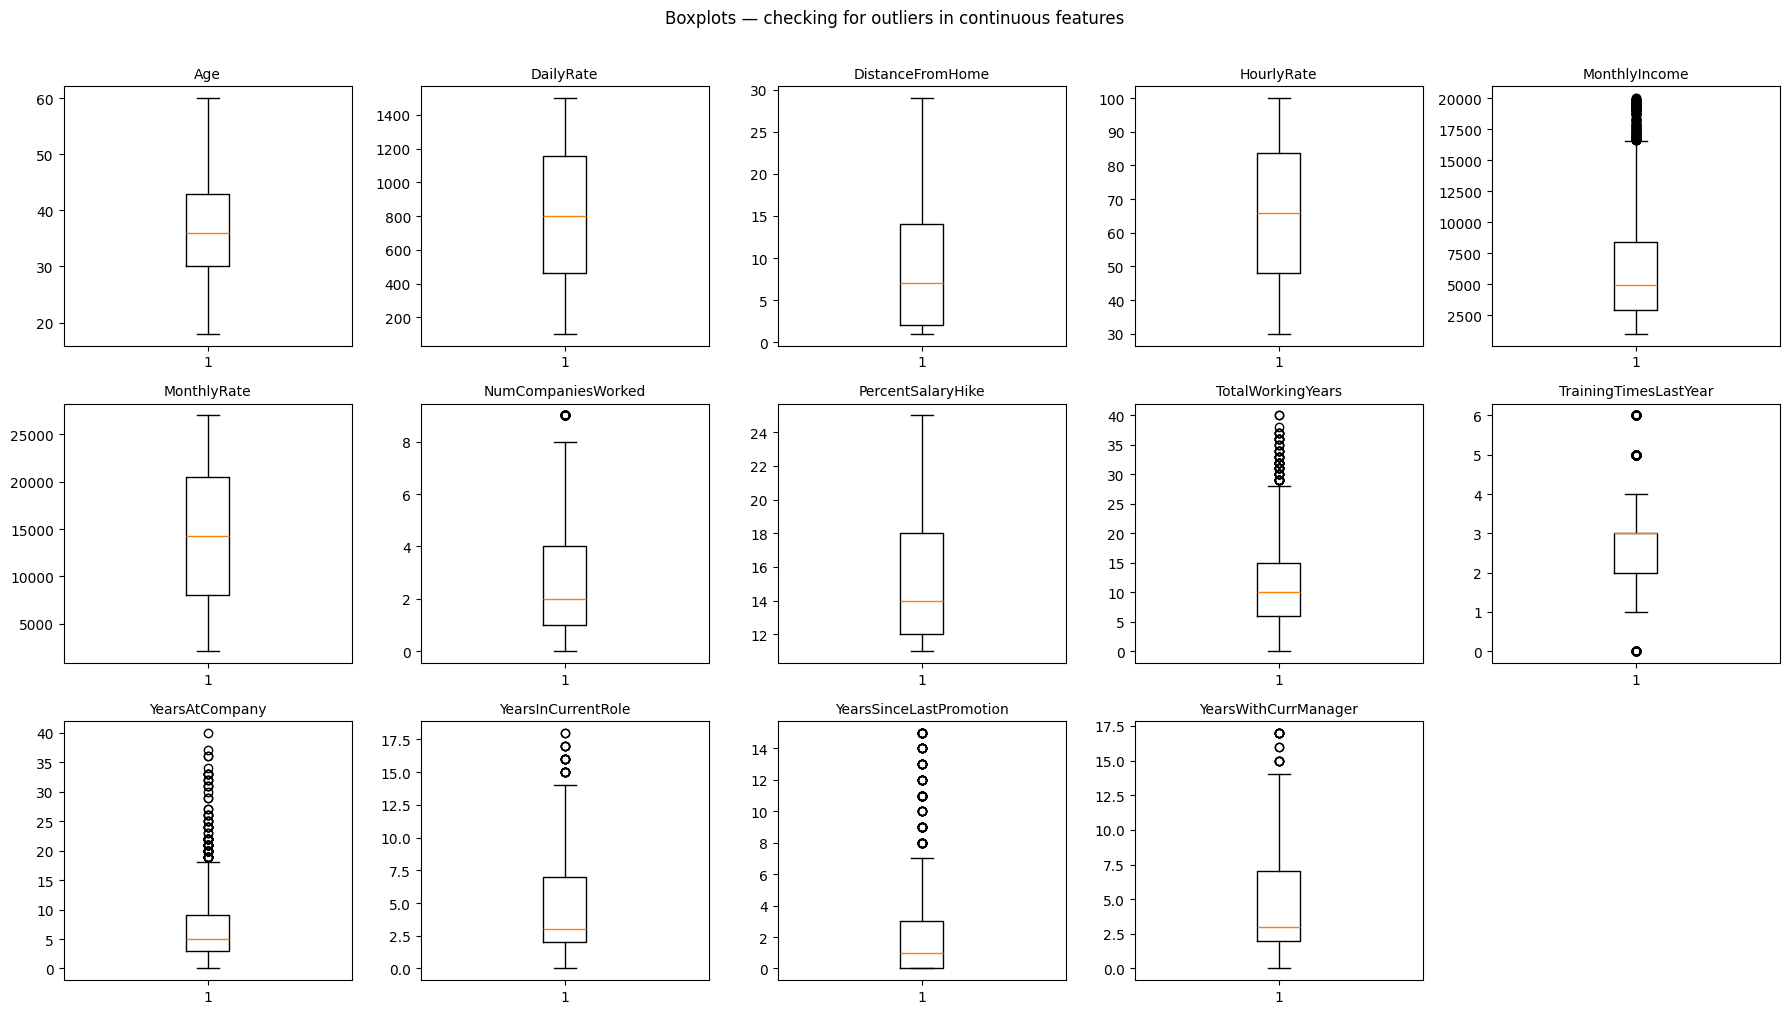

In [9]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
for ax, col in zip(axes.flatten(), continuous_cols):
    ax.boxplot(df[col], vert=True)  # one boxplot per continuous feature
    ax.set_title(col, fontsize=10)
for ax in axes.flatten()[len(continuous_cols):]:
    ax.axis('off')  # hide unused grid slots
plt.suptitle('Boxplots — checking for outliers in continuous features', y=1.01)
plt.tight_layout()
plt.show()

### II.5 Outlier Percentage (IQR Rule)

In [10]:
def iqr_outlier_share(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)  # quartiles
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr  # standard IQR fence
    return ((series < lower) | (series > upper)).mean() * 100  # % flagged as outliers

print("Share of values flagged as outliers by the 1.5*IQR rule:")
for col in continuous_cols:
    pct = iqr_outlier_share(df[col])  # per-column outlier %
    print(f"  {col:<24}: {pct:.2f}%")

Share of values flagged as outliers by the 1.5*IQR rule:
  Age                     : 0.00%
  DailyRate               : 0.00%
  DistanceFromHome        : 0.00%
  HourlyRate              : 0.00%
  MonthlyIncome           : 7.76%
  MonthlyRate             : 0.00%
  NumCompaniesWorked      : 3.54%
  PercentSalaryHike       : 0.00%
  TotalWorkingYears       : 4.29%
  TrainingTimesLastYear   : 16.19%
  YearsAtCompany          : 7.07%
  YearsInCurrentRole      : 1.43%
  YearsSinceLastPromotion : 7.28%
  YearsWithCurrManager    : 0.95%


### II.6 Feature vs Attrition

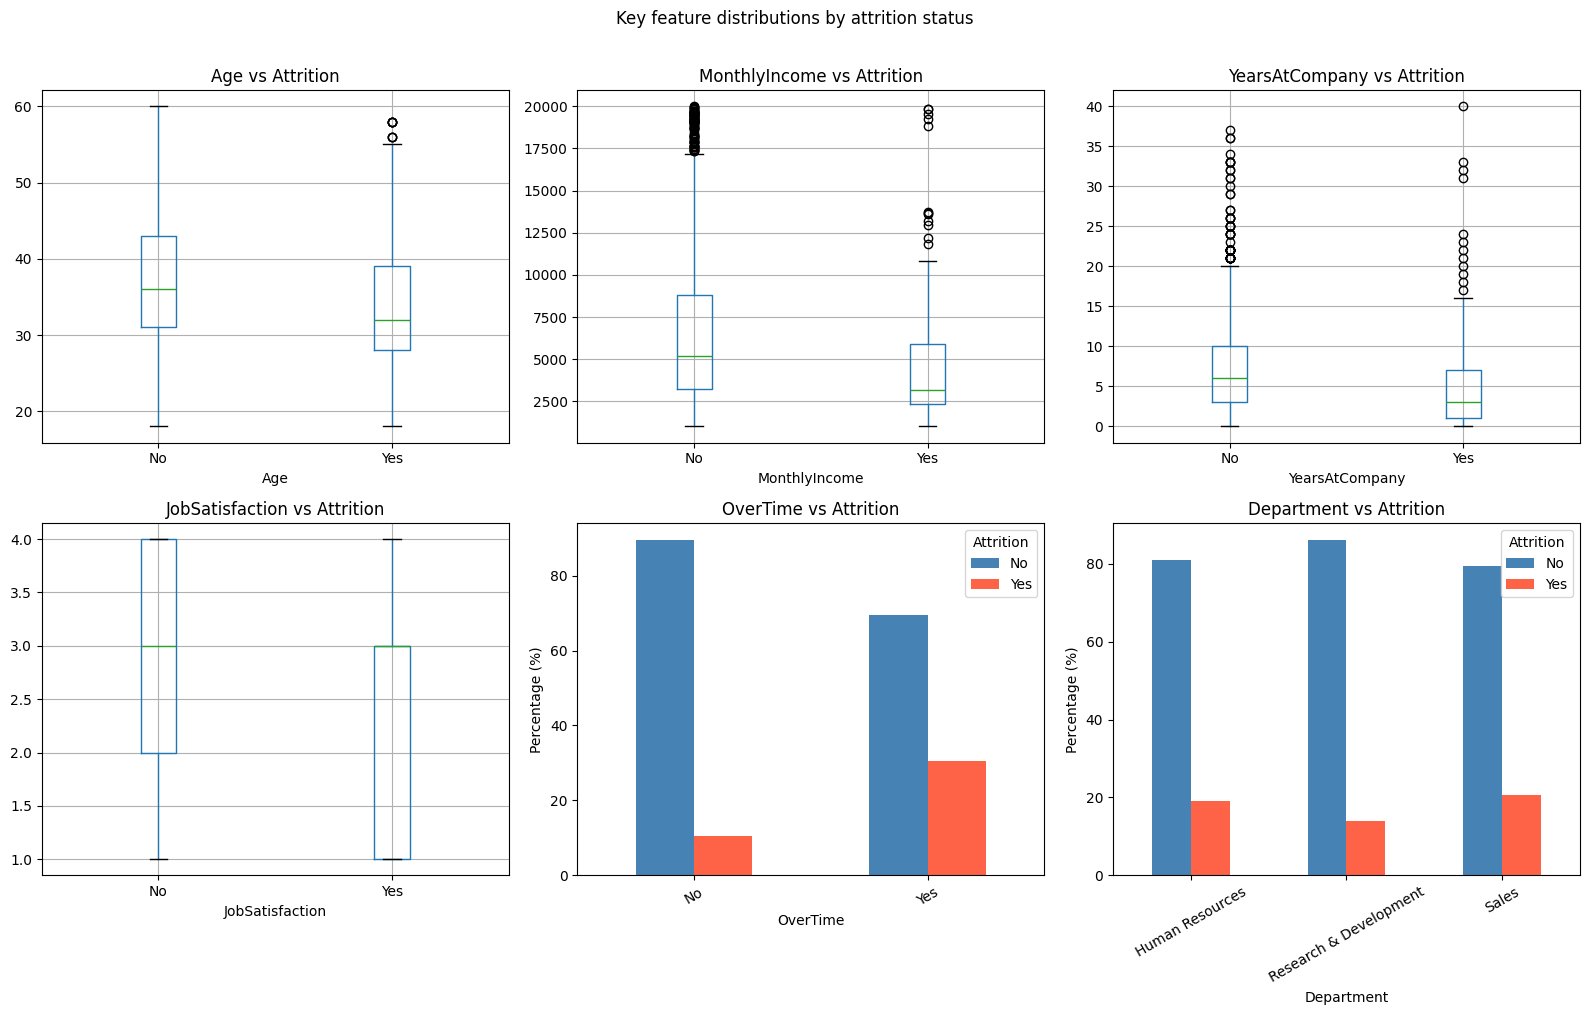

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features_to_plot = ['Age', 'MonthlyIncome', 'YearsAtCompany',
                    'JobSatisfaction', 'OverTime', 'Department']  # quick-look features

for ax, feat in zip(axes.flatten(), features_to_plot):
    if df[feat].dtype == 'object':
        # categorical -> stacked bar of attrition rate per category
        ct = pd.crosstab(df[feat], df['Attrition'], normalize='index') * 100
        ct.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
        ax.set_ylabel('Percentage (%)')
        ax.tick_params(axis='x', rotation=30)
    else:
        # numeric -> boxplot split by attrition status
        df.boxplot(column=feat, by='Attrition', ax=ax)
        ax.set_title('')
    ax.set_xlabel(feat)
    ax.set_title(f'{feat} vs Attrition')

plt.suptitle('Key feature distributions by attrition status', y=1.01)
plt.tight_layout()
plt.show()

### II.7 Correlation Heatmap

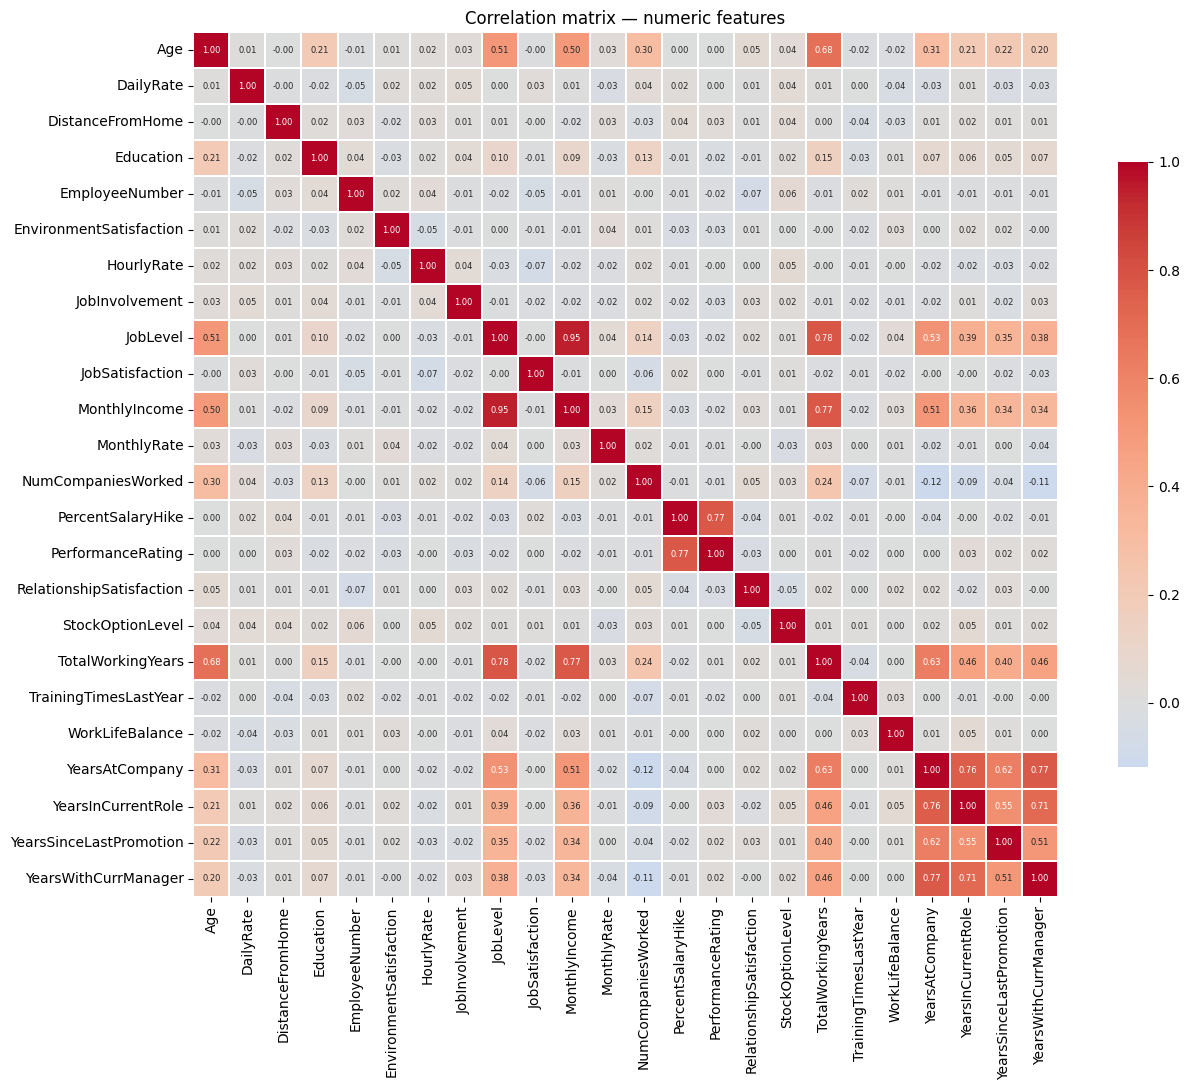

In [12]:
numeric_df = df.select_dtypes(include=[np.number])  # numeric-only view for correlation
numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]  # drop constant cols (e.g. EmployeeCount, StandardHours) -> avoid NaN corr
corr = numeric_df.corr()  # pairwise Pearson correlation

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, square=True,
            linewidths=0.3, cbar_kws={'shrink': 0.7},
            annot=True, fmt='.2f', annot_kws={'size': 6})  # values inside each grid cell
ax.set_title('Correlation matrix — numeric features')
plt.tight_layout()
plt.show()

### II.8 Correlation with Target

In [13]:
# correlation of every numeric feature with the (numeric-encoded) target
target_corr = df.assign(Attrition_num=df['Attrition'].map({'Yes': 1, 'No': 0})) \
                .select_dtypes(include=[np.number]) \
                .corr()['Attrition_num'].drop('Attrition_num') \
                .dropna() \
                .sort_values(key=abs, ascending=False)  # drop constant cols (NaN corr)

print("Correlation with Attrition (numeric features):")
print(target_corr.head(15).round(3))


Correlation with Attrition (numeric features):
TotalWorkingYears         -0.171
JobLevel                  -0.169
YearsInCurrentRole        -0.161
MonthlyIncome             -0.160
Age                       -0.159
YearsWithCurrManager      -0.156
StockOptionLevel          -0.137
YearsAtCompany            -0.134
JobInvolvement            -0.130
JobSatisfaction           -0.103
EnvironmentSatisfaction   -0.103
DistanceFromHome           0.078
WorkLifeBalance           -0.064
TrainingTimesLastYear     -0.059
DailyRate                 -0.057
Name: Attrition_num, dtype: float64


## III. Data Cleaning & Preprocessing

### III.1 Detect Outliers — IQR Bounds Function

In [14]:
def get_iqr_bounds(series, k=1.5):
    # Q1, Q3, IQR -> lower/upper bound
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr  # fence used to flag/cap outliers
    return lower, upper

In [15]:
def flag_outliers_iqr(df, cols, k=1.5):
    # boolean mask, True = value outside IQR bounds
    mask = pd.DataFrame(False, index=df.index, columns=cols)
    for col in cols:
        lower, upper = get_iqr_bounds(df[col], k)  # per-column fence
        mask[col] = (df[col] < lower) | (df[col] > upper)
    return mask

### III.2 Outlier Report Before Cleaning

In [16]:
outlier_mask = flag_outliers_iqr(df, continuous_cols)          # per-column mask
outlier_counts = outlier_mask.sum().sort_values(ascending=False)  # count per column
outlier_pct = (outlier_counts / len(df) * 100).round(2)        # percentage per column

print("Outlier counts (1.5*IQR rule):")
print(outlier_counts)
print("\nOutlier percentage:")
print(outlier_pct)

rows_with_any_outlier = outlier_mask.any(axis=1).sum()  # rows flagged in >=1 column
print(f"\nRows with at least one outlier: {rows_with_any_outlier} "
      f"({rows_with_any_outlier/len(df)*100:.2f}%)")

Outlier counts (1.5*IQR rule):
TrainingTimesLastYear      238
MonthlyIncome              114
YearsSinceLastPromotion    107
YearsAtCompany             104
TotalWorkingYears           63
NumCompaniesWorked          52
YearsInCurrentRole          21
YearsWithCurrManager        14
MonthlyRate                  0
DailyRate                    0
Age                          0
HourlyRate                   0
DistanceFromHome             0
PercentSalaryHike            0
dtype: int64

Outlier percentage:
TrainingTimesLastYear      16.19
MonthlyIncome               7.76
YearsSinceLastPromotion     7.28
YearsAtCompany              7.07
TotalWorkingYears           4.29
NumCompaniesWorked          3.54
YearsInCurrentRole          1.43
YearsWithCurrManager        0.95
MonthlyRate                 0.00
DailyRate                   0.00
Age                         0.00
HourlyRate                  0.00
DistanceFromHome            0.00
PercentSalaryHike           0.00
dtype: float64

Rows with at least one 

### III.3 Cap Outliers — IQR Capping Function

In [17]:
def cap_outliers_iqr(df, cols, k=1.5):
    # clip values outside IQR bounds (row count preserved, no data loss)
    df = df.copy()
    for col in cols:
        lower, upper = get_iqr_bounds(df[col], k)  # reuse the same fence logic
        df[col] = df[col].clip(lower, upper)
    return df

### III.4 Apply Outlier Capping

Outlier % after capping:
Age                        0.0
DailyRate                  0.0
DistanceFromHome           0.0
HourlyRate                 0.0
MonthlyIncome              0.0
MonthlyRate                0.0
NumCompaniesWorked         0.0
PercentSalaryHike          0.0
TotalWorkingYears          0.0
TrainingTimesLastYear      0.0
YearsAtCompany             0.0
YearsInCurrentRole         0.0
YearsSinceLastPromotion    0.0
YearsWithCurrManager       0.0
dtype: float64


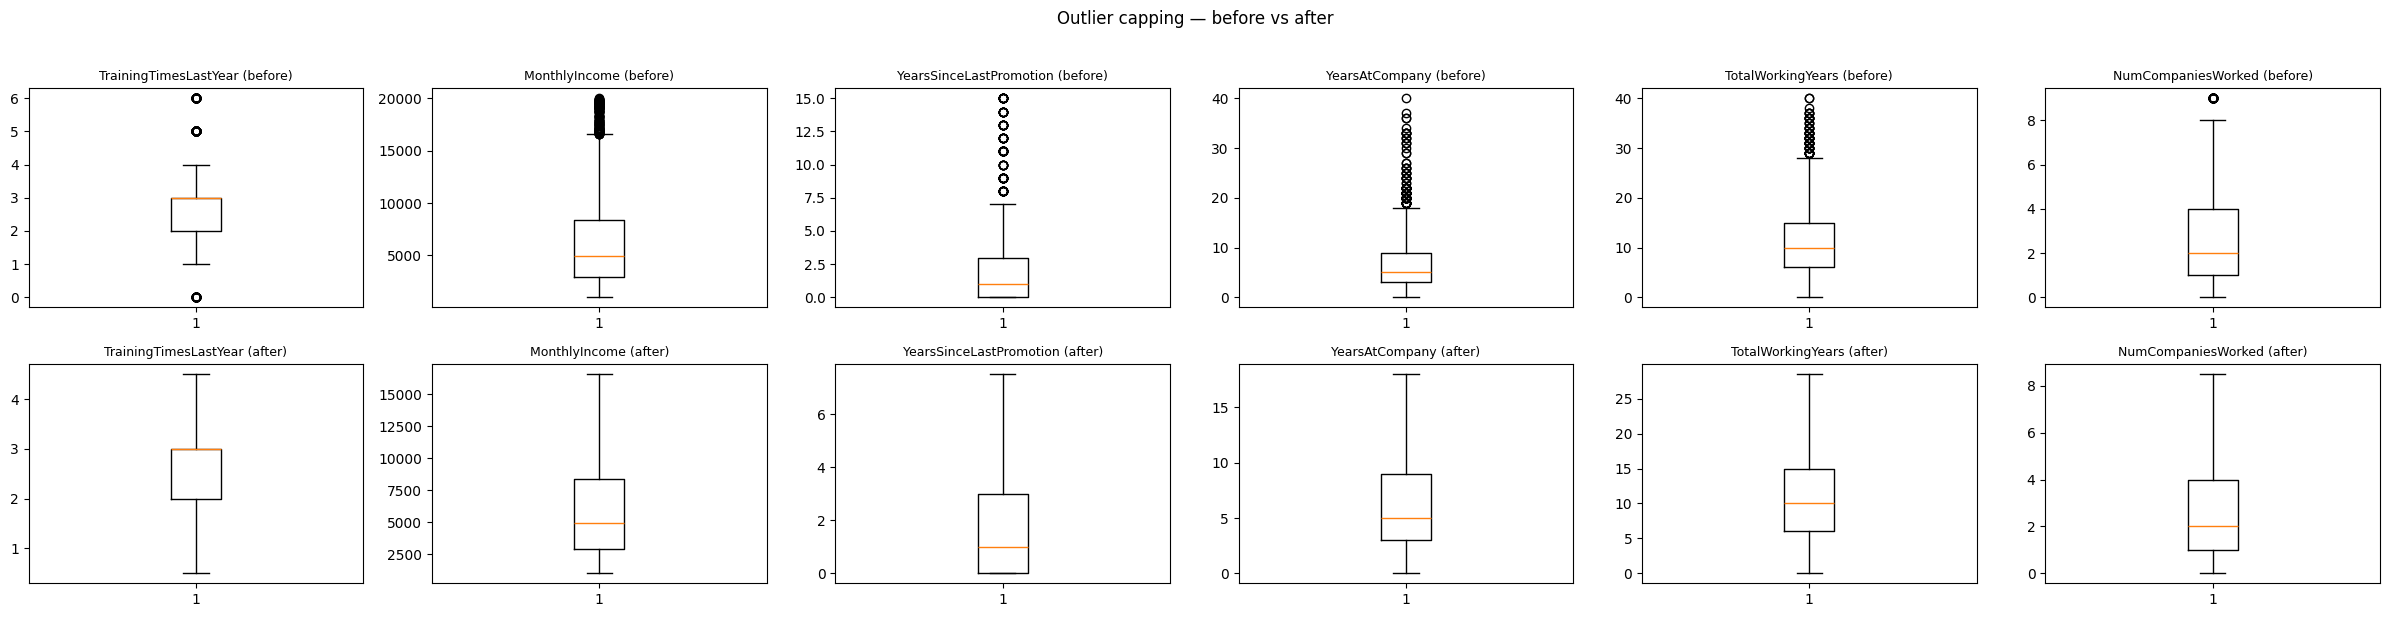

In [18]:
df_before_capping = df.copy()                       # keep copy for before/after check
df = cap_outliers_iqr(df, continuous_cols, k=1.5)   # cap outliers on working df

outlier_mask_after = flag_outliers_iqr(df, continuous_cols)  # re-check after capping
print("Outlier % after capping:")
print((outlier_mask_after.sum() / len(df) * 100).round(2))

# before vs after boxplots for columns that actually had outliers
cols_to_check = outlier_counts[outlier_counts > 0].index[:6]
fig, axes = plt.subplots(2, len(cols_to_check), figsize=(4*len(cols_to_check), 6))
for j, col in enumerate(cols_to_check):
    axes[0, j].boxplot(df_before_capping[col])   # before
    axes[0, j].set_title(f'{col} (before)', fontsize=9)
    axes[1, j].boxplot(df[col])                  # after
    axes[1, j].set_title(f'{col} (after)', fontsize=9)
plt.suptitle('Outlier capping — before vs after', y=1.02)
plt.tight_layout()
plt.show()

### III.5 Identify Highly Correlated Feature Pairs — Function

In [19]:
def get_high_corr_pairs(df, threshold=0.85):
    # numeric pairs with |corr| above threshold, upper triangle only (no duplicates)
    numeric = df.select_dtypes(include=[np.number])
    corr_matrix = numeric.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # mask lower triangle + diagonal
    pairs = []
    for col in upper.columns:
        for row in upper.index:
            val = upper.loc[row, col]
            if pd.notna(val) and val > threshold:
                pairs.append((row, col, round(val, 3)))  # collect (feat_a, feat_b, corr)
    return sorted(pairs, key=lambda x: -x[2])  # strongest correlation first

### III.6 Drop Highly Correlated Columns

In [20]:
high_corr_pairs = get_high_corr_pairs(df, threshold=0.85)   # from II.7 heatmap pattern
print("Highly correlated pairs (|corr| > 0.85):")
for a, b, v in high_corr_pairs:
    print(f"  {a} <-> {b}: {v}")

# keep the first column of each pair, drop the second (never drop the target)
cols_to_drop = set()
for a, b, v in high_corr_pairs:
    if b != 'Attrition' and b not in cols_to_drop:
        cols_to_drop.add(b)

print(f"\nDropping columns due to high correlation: {sorted(cols_to_drop)}")
df = df.drop(columns=list(cols_to_drop))  # remove redundant features

continuous_cols = [c for c in continuous_cols if c not in cols_to_drop]  # keep in sync
print("Updated dataframe shape:", df.shape)

Highly correlated pairs (|corr| > 0.85):
  JobLevel <-> MonthlyIncome: 0.946

Dropping columns due to high correlation: ['MonthlyIncome']
Updated dataframe shape: (1470, 34)


### III.7 Drop Columns & Encode Target

In [21]:
drop_cols = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']  # no predictive value
df = df.drop(columns=drop_cols)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})  # encode target to 0/1
print(df['Attrition'].value_counts())


Attrition
0    1233
1     237
Name: count, dtype: int64


### III.8 Detect Categorical Columns — Label vs One-Hot Function

In [22]:
def get_encoding_groups(df, exclude=None):
    # object columns need encoding; ordinal ratings are already numeric
    exclude = exclude or []
    cat_cols = [c for c in df.select_dtypes(include='object').columns if c not in exclude]

    # binary (2 unique values) -> label encoding, multi-class -> one-hot encoding
    binary_cols = [c for c in cat_cols if df[c].nunique() == 2]
    nominal_cols = [c for c in cat_cols if df[c].nunique() > 2]
    return binary_cols, nominal_cols

### III.9 Apply Encoding (Label + One-Hot)

In [23]:
from sklearn.preprocessing import LabelEncoder

binary_cols, nominal_cols = get_encoding_groups(df, exclude=['Attrition'])
print("Binary columns (label encoded):", binary_cols)
print("Nominal columns (one-hot encoded):", nominal_cols)

# label encode binary columns (e.g. OverTime, Gender) -> single 0/1 column
for col in binary_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# one-hot encode remaining multi-class nominal columns
df = pd.get_dummies(df, columns=nominal_cols)

print(df.shape)  # confirm expanded width after one-hot encoding

Binary columns (label encoded): ['Gender', 'OverTime']
Nominal columns (one-hot encoded): ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
(1470, 49)


### III.10 Build Feature Matrix

In [24]:
feature_names = df.drop(columns=['Attrition']).columns.tolist()  # column order used everywhere downstream

X = df.drop(columns=['Attrition']).values.astype(np.float32)  # feature matrix
y = df['Attrition'].values.astype(int)  # target vector

# raw, unscaled features — scaling happens per fold, after the split
print(X.shape, y.shape)
print(f"No: {(y==0).sum()}  Yes: {(y==1).sum()}")

continuous_idx = [feature_names.index(c) for c in continuous_cols]  # positions for per-fold capping
print("continuous feature indices for outlier capping:", continuous_idx)

(1470, 48) (1470,)
No: 1233  Yes: 237
continuous feature indices for outlier capping: [0, 1, 2, 6, 10, 11, 13, 17, 18, 20, 21, 22, 23]


## IV. Cross-Validation Setup

In [25]:
def compute_metrics(y_true, y_pred, y_prob):
    # one shared metrics dict used by all 3 models for a fair comparison
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
    }

In [26]:
def cap_outliers(X_train, X_val, idx, k=1.5):
    # IQR bounds fit on the training rows only, then applied to both splits
    X_train = X_train.copy()
    X_val = X_val.copy()
    for i in idx:
        q1, q3 = np.percentile(X_train[:, i], [25, 75])  # fence from train fold only
        iqr = q3 - q1
        lower, upper = q1 - k * iqr, q3 + k * iqr
        X_train[:, i] = np.clip(X_train[:, i], lower, upper)
        X_val[:, i] = np.clip(X_val[:, i], lower, upper)  # same fence applied to val
    return X_train, X_val

In [27]:
def scale_fold(X_train, X_val):
    # scaler fit on train fold only, then applied to val fold (no leakage)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    return X_train_scaled, X_val_scaled

In [28]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)  # outer CV
INNER_SPLITS = 3
inner_skf = StratifiedKFold(n_splits=INNER_SPLITS, shuffle=True, random_state=RANDOM_STATE)  # nested CV for OOF stacking

smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.5)  # oversample minority (attrition) class

In [29]:
# baseline TabNet params (used only by the standalone TabNet model, section IV.1)
tabnet_params = dict(
    n_d=16, n_a=16, n_steps=4, gamma=1.5, lambda_sparse=1e-3,
    optimizer_fn=torch.optim.Adam, optimizer_params={'lr': 1.5e-2},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={'step_size': 10, 'gamma': 0.9},
    mask_type='sparsemax', seed=RANDOM_STATE, device_name=DEVICE, verbose=0,
)

# baseline LightGBM params (used only by the standalone LightGBM model, section IV.2)
lgbm_params = dict(
    n_estimators=300, learning_rate=0.05, num_leaves=31,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)

# hybrid-only TabNet params: wider/deeper than the baseline above
tabnet_hybrid_params = dict(tabnet_params)
tabnet_hybrid_params.update(
    n_d=32, n_a=32, n_steps=6, gamma=1.7, lambda_sparse=1e-3,
    optimizer_params={'lr': 1.2e-2},
)

In [30]:
def find_best_threshold(y_true, y_prob, metric='f1'):
    # scan thresholds, keep the one maximising F1 (or accuracy) on OOF probs
    best_thr, best_score = 0.5, -1
    for thr in np.arange(0.05, 0.96, 0.01):
        y_hat = (y_prob >= thr).astype(int)
        score = (f1_score(y_true, y_hat, zero_division=0) if metric == 'f1'
                  else accuracy_score(y_true, y_hat))
        if score > best_score:
            best_score, best_thr = score, thr
    return best_thr




In [31]:
def cv_threshold_probe(X_train_raw, y_train, continuous_idx, fit_fn, predict_fn):
    # inner CV just to pick a decision threshold without touching the outer val fold
    oof_prob = np.zeros(len(y_train))
    for tr_idx, va_idx in inner_skf.split(X_train_raw, y_train):
        X_tr_raw, X_va_raw = X_train_raw[tr_idx], X_train_raw[va_idx]
        y_tr = y_train[tr_idx]
        X_tr, X_va = cap_outliers(X_tr_raw, X_va_raw, continuous_idx)
        X_tr, X_va = scale_fold(X_tr, X_va)
        X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)
        model = fit_fn(X_tr_res, y_tr_res)
        oof_prob[va_idx] = predict_fn(model, X_va)
    return find_best_threshold(y_train, oof_prob, metric='f1')


pipeline_start = time.perf_counter()  # stopwatch covering all 3 models below

### IV.1 TabNet Baseline

In [32]:
tabnet_start = time.perf_counter()  # timer for this model's total training time

tabnet_fold_results = []
tabnet_attention_masks = []
tabnet_oof_true, tabnet_oof_pred, tabnet_oof_prob = [], [], []

# tqdm wraps the fold loop -> progress bar with live ETA for the 5 folds
for fold, (train_idx, val_idx) in tqdm(enumerate(skf.split(X, y), 1),
                                        total=N_SPLITS, desc='TabNet folds'):
    fold_start = time.perf_counter()  # per-fold timer

    X_train_raw, X_val_raw = X[train_idx], X[val_idx]  # raw (unscaled) split for this fold
    y_train, y_val = y[train_idx], y[val_idx]

    X_train, X_val = cap_outliers(X_train_raw, X_val_raw, continuous_idx)  # cap on train, apply to val
    X_train, X_val = scale_fold(X_train, X_val)  # min-max scale, fit on train only
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)  # oversample minority class

    def _fit_tabnet(Xr, yr):
        # small/fast fit used only inside the threshold probe above
        m = TabNetClassifier(**tabnet_params)
        m.fit(Xr, yr, max_epochs=40, patience=12, batch_size=256,
              virtual_batch_size=128, num_workers=0, drop_last=False)
        return m
    best_thr = cv_threshold_probe(X_train_raw, y_train, continuous_idx,
                                   fit_fn=_fit_tabnet,
                                   predict_fn=lambda m, Xv: m.predict_proba(Xv)[:, 1])

    model = TabNetClassifier(**tabnet_params)  # final fold model, full training budget
    model.fit(
        X_train_res, y_train_res,
        eval_set=[(X_val, y_val)], eval_metric=['auc'],
        max_epochs=100, patience=20, batch_size=256, virtual_batch_size=128,
        num_workers=0, drop_last=False,
    )

    y_prob = model.predict_proba(X_val)[:, 1]
    y_pred = (y_prob >= best_thr).astype(int)  # tuned threshold, not a fixed 0.5
    _, masks = model.explain(X_val)  # per-sample attention masks for interpretability
    tabnet_attention_masks.append(masks)

    tabnet_oof_true.extend(y_val)
    tabnet_oof_pred.extend(y_pred)
    tabnet_oof_prob.extend(y_prob)

    metrics = compute_metrics(y_val, y_pred, y_prob)
    tabnet_fold_results.append(metrics)
    tqdm.write(f"fold {fold}: acc={metrics['accuracy']:.4f} prec={metrics['precision']:.4f} "
               f"rec={metrics['recall']:.4f} f1={metrics['f1']:.4f} auc={metrics['roc_auc']:.4f} "
               f"thr={best_thr:.2f} | {time.perf_counter() - fold_start:.1f}s")

tabnet_df = pd.DataFrame(tabnet_fold_results)
tabnet_summary = tabnet_df.agg(['mean', 'std'])  # mean/std across the 5 folds
print(tabnet_summary.round(4))
print(f"TabNet total training time: {time.perf_counter() - tabnet_start:.1f}s")

TabNet folds:   0%|          | 0/5 [00:00<?, ?it/s]


Early stopping occurred at epoch 43 with best_epoch = 23 and best_val_0_auc = 0.70672
fold 1: acc=0.5816 prec=0.2449 rec=0.7500 f1=0.3692 auc=0.7067 thr=0.19 | 37.6s

Early stopping occurred at epoch 36 with best_epoch = 16 and best_val_0_auc = 0.72375
fold 2: acc=0.8265 prec=0.4483 rec=0.2708 f1=0.3377 auc=0.7237 thr=0.46 | 22.1s

Early stopping occurred at epoch 45 with best_epoch = 25 and best_val_0_auc = 0.74201
fold 3: acc=0.7007 prec=0.2842 rec=0.5745 f1=0.3803 auc=0.7420 thr=0.35 | 24.0s

Early stopping occurred at epoch 28 with best_epoch = 8 and best_val_0_auc = 0.68447
fold 4: acc=0.8299 prec=0.3846 rec=0.1064 f1=0.1667 auc=0.6845 thr=0.41 | 22.5s

Early stopping occurred at epoch 60 with best_epoch = 40 and best_val_0_auc = 0.72409
fold 5: acc=0.8333 prec=0.4643 rec=0.2766 f1=0.3467 auc=0.7241 thr=0.45 | 27.3s
      accuracy  precision  recall      f1  roc_auc
mean    0.7544     0.3653  0.3957  0.3201   0.7162
std     0.1117     0.0976  0.2603  0.0875   0.0217
TabNet total 

### IV.2 LightGBM Baseline

In [33]:
lgbm_start = time.perf_counter()  # timer for this model's total training time

lgbm_fold_results = []
lgbm_feature_importances = []
lgbm_oof_true, lgbm_oof_pred, lgbm_oof_prob = [], [], []

# tqdm wraps the fold loop -> progress bar with live ETA for the 5 folds
for fold, (train_idx, val_idx) in tqdm(enumerate(skf.split(X, y), 1),
                                        total=N_SPLITS, desc='LightGBM folds'):
    fold_start = time.perf_counter()  # per-fold timer

    X_train_raw, X_val_raw = X[train_idx], X[val_idx]  # raw (unscaled) split for this fold
    y_train, y_val = y[train_idx], y[val_idx]

    X_train, X_val = cap_outliers(X_train_raw, X_val_raw, continuous_idx)  # cap on train, apply to val
    X_train, X_val = scale_fold(X_train, X_val)  # min-max scale, fit on train only
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)  # oversample minority class

    # same inner-CV F1 threshold tuning as TabNet and the Hybrid model
    def _fit_lgbm(Xr, yr):
        m = lgb.LGBMClassifier(**lgbm_params)
        m.fit(Xr, yr)
        return m
    best_thr = cv_threshold_probe(X_train_raw, y_train, continuous_idx,
                                   fit_fn=_fit_lgbm,
                                   predict_fn=lambda m, Xv: m.predict_proba(Xv)[:, 1])

    model = lgb.LGBMClassifier(**lgbm_params)  # final fold model
    model.fit(
        X_train_res, y_train_res,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
    )

    y_prob = model.predict_proba(X_val)[:, 1]
    y_pred = (y_prob >= best_thr).astype(int)  # tuned threshold, not a fixed 0.5
    lgbm_feature_importances.append(model.feature_importances_)  # for section VII.1

    lgbm_oof_true.extend(y_val)
    lgbm_oof_pred.extend(y_pred)
    lgbm_oof_prob.extend(y_prob)

    metrics = compute_metrics(y_val, y_pred, y_prob)
    lgbm_fold_results.append(metrics)
    tqdm.write(f"fold {fold}: acc={metrics['accuracy']:.4f} prec={metrics['precision']:.4f} "
               f"rec={metrics['recall']:.4f} f1={metrics['f1']:.4f} auc={metrics['roc_auc']:.4f} "
               f"thr={best_thr:.2f} | {time.perf_counter() - fold_start:.1f}s")

lgbm_df = pd.DataFrame(lgbm_fold_results)
lgbm_summary = lgbm_df.agg(['mean', 'std'])  # mean/std across the 5 folds
print(lgbm_summary.round(4))
print(f"LightGBM total training time: {time.perf_counter() - lgbm_start:.1f}s")

LightGBM folds:   0%|          | 0/5 [00:00<?, ?it/s]

fold 1: acc=0.6156 prec=0.2759 rec=0.8333 f1=0.4145 auc=0.8034 thr=0.11 | 1.3s
fold 2: acc=0.6429 prec=0.2756 rec=0.7292 f1=0.4000 auc=0.7752 thr=0.11 | 1.2s
fold 3: acc=0.8367 prec=0.4872 rec=0.4043 f1=0.4419 auc=0.7985 thr=0.35 | 1.2s
fold 4: acc=0.7891 prec=0.4051 rec=0.6809 f1=0.5079 auc=0.8144 thr=0.14 | 1.2s
fold 5: acc=0.7687 prec=0.3895 rec=0.7872 f1=0.5211 auc=0.8075 thr=0.15 | 1.2s
      accuracy  precision  recall      f1  roc_auc
mean    0.7306     0.3666  0.6870  0.4571   0.7998
std     0.0962     0.0909  0.1682  0.0548   0.0149
LightGBM total training time: 6.1s


### IV.3 Hybrid Model (TabNet + LightGBM)


#### IV.3.1 TabNet + Residual-Corrector — Fold Fitting Function


In [34]:
def fit_tabnet_and_residual_corrector(X_train, y_train, epochs, patience, eval_set=None):
    """
    Implements the 3-step residual-ensemble design (Methodology Ch.3, Section 3.3):
      1) Train TabNet on SMOTE-balanced data.
      2) Compute residuals R = y_true - P_TabNet on the natural (non-resampled)
         training rows, using THIS SAME trained TabNet -- not a separate
         nested-CV model -- so the corrector learns to fix exactly the model
         that produces the final prediction (no train/serve mismatch).
      3) Train a LightGBM regressor on the original features to predict R,
         directing its gradient-boosting capacity at the instances TabNet
         misclassifies, per Ranglani's (2025) residual-aware stacking design.
    """
    # Step 1: TabNet on SMOTE-balanced data
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    tabnet_model = TabNetClassifier(**tabnet_hybrid_params)
    tabnet_model.fit(
        X_train_res, y_train_res,
        eval_set=eval_set if eval_set is not None else [(X_train, y_train)],
        eval_metric=['auc'], max_epochs=epochs, patience=patience,
        batch_size=256, virtual_batch_size=128, num_workers=0, drop_last=False,
    )

    # Step 2: residuals from THIS TabNet, on the natural training rows
    tabnet_train_prob = tabnet_model.predict_proba(X_train)[:, 1]
    residual_train = y_train.astype(np.float32) - tabnet_train_prob

    # Step 3: LightGBM corrector. Sample weights follow the TRUE class-imbalance
    # ratio (~84:16) rather than an arbitrary constant, so the many near-zero
    # residuals from confidently-correct majority cases don't drown out the
    # minority-class errors the corrector is meant to fix.
    pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    sample_w = np.where(y_train == 1, pos_weight, 1.0)
    corrector = lgb.LGBMRegressor(**lgbm_hybrid_params)
    corrector.fit(X_train, residual_train, sample_weight=sample_w)

    return tabnet_model, corrector


def predict_hybrid(tabnet_model, corrector, X):
    # P_Hybrid = P_TabNet + predicted correction, clipped to a valid probability
    tabnet_prob = tabnet_model.predict_proba(X)[:, 1]
    correction = corrector.predict(X)
    return np.clip(tabnet_prob + correction, 0.0, 1.0)


#### IV.3.2 Threshold Selection via Inner Cross-Validation


In [ ]:
def cv_threshold_probe_hybrid(X_train_raw, y_train, continuous_idx):
    # Inner CV using the EXACT same fit/predict as the final model
    # so the chosen decision threshold reflects genuinely held-out performance
    # and never touches the outer validation fold.
    oof_prob = np.zeros(len(y_train))
    for tr_idx, va_idx in inner_skf.split(X_train_raw, y_train):
        X_tr_raw, X_va_raw = X_train_raw[tr_idx], X_train_raw[va_idx]
        y_tr, y_va = y_train[tr_idx], y_train[va_idx]

        X_tr, X_va = cap_outliers(X_tr_raw, X_va_raw, continuous_idx)
        X_tr, X_va = scale_fold(X_tr, X_va)

        tabnet_probe, corrector_probe = fit_tabnet_and_residual_corrector(
            X_tr, y_tr, epochs=90, patience=20, eval_set=[(X_va, y_va)]
        )
        oof_prob[va_idx] = predict_hybrid(tabnet_probe, corrector_probe, X_va)
    return find_best_threshold(y_train, oof_prob, metric='f1')


#### IV.3.3 Residual-Corrector LightGBM Parameters


In [36]:
# residual-corrector LightGBM: more capacity than the baseline, trained as a
# regressor on TabNet's residuals. objective='huber' makes the fit robust to
# the occasional large residual (a hard-misclassified minority case) without
# letting a few extreme values dominate the loss the way plain L2 would.
lgbm_hybrid_params = dict(lgbm_params)
lgbm_hybrid_params.update(
    n_estimators=700, num_leaves=71, learning_rate=0.04,
    min_child_samples=12, subsample=0.85, colsample_bytree=0.85,
    reg_alpha=0.05, reg_lambda=0.15, objective='huber',
)


#### IV.3.4 Hybrid Training Loop — Residual-Correction Pipeline


In [ ]:
hybrid_start = time.perf_counter()  # timer for this model's total training time
hybrid_fold_results = []
hybrid_lgbm_importances = []
hybrid_oof_true, hybrid_oof_pred, hybrid_oof_prob = [], [], []

for fold, (train_idx, val_idx) in tqdm(enumerate(skf.split(X, y), 1),
                                        total=N_SPLITS, desc='Hybrid outer folds'):
    fold_start = time.perf_counter()  # per-fold timer

    X_train_raw, X_val_raw = X[train_idx], X[val_idx]  # raw (unscaled) split for this fold
    y_train, y_val = y[train_idx], y[val_idx]

    X_train, X_val = cap_outliers(X_train_raw, X_val_raw, continuous_idx)
    X_train, X_val = scale_fold(X_train, X_val)

    # Step A: honest decision threshold via inner CV, using the exact same
    # residual-ensemble recipe as the final model below (no leakage from X_val)
    best_thr = cv_threshold_probe_hybrid(X_train_raw, y_train, continuous_idx)

    # Step B: final TabNet + residual corrector, fit ONCE on the full outer-train
    # fold. This is the same model object used both to compute the training
    # residuals and to predict the validation fold -> no train/serve mismatch.
    tabnet_final, lgbm_corrector = fit_tabnet_and_residual_corrector(
        X_train, y_train, epochs=150, patience=25, eval_set=[(X_val, y_val)]
    )

    y_prob = predict_hybrid(tabnet_final, lgbm_corrector, X_val)  # P_TabNet + correction
    y_pred = (y_prob >= best_thr).astype(int)  # tuned threshold, not a fixed 0.5

    hybrid_lgbm_importances.append(lgbm_corrector.feature_importances_)

    hybrid_oof_true.extend(y_val)
    hybrid_oof_pred.extend(y_pred)
    hybrid_oof_prob.extend(y_prob)

    metrics = compute_metrics(y_val, y_pred, y_prob)
    hybrid_fold_results.append(metrics)
    tqdm.write(f"fold {fold}: acc={metrics['accuracy']:.4f} prec={metrics['precision']:.4f} "
               f"rec={metrics['recall']:.4f} f1={metrics['f1']:.4f} auc={metrics['roc_auc']:.4f} "
               f"thr={best_thr:.2f} | {time.perf_counter() - fold_start:.1f}s")

hybrid_df = pd.DataFrame(hybrid_fold_results)
hybrid_summary = hybrid_df.agg(['mean', 'std'])  # mean/std across the 5 folds
print(hybrid_summary.round(4))
print(f"Hybrid total training time: {time.perf_counter() - hybrid_start:.1f}s")


Hybrid outer folds:   0%|          | 0/5 [00:00<?, ?it/s]


Early stopping occurred at epoch 38 with best_epoch = 18 and best_val_0_auc = 0.66324

Early stopping occurred at epoch 64 with best_epoch = 44 and best_val_0_auc = 0.70512

Early stopping occurred at epoch 40 with best_epoch = 20 and best_val_0_auc = 0.68201

Early stopping occurred at epoch 52 with best_epoch = 27 and best_val_0_auc = 0.69309
fold 1: acc=0.8129 prec=0.4186 rec=0.3750 f1=0.3956 auc=0.7492 thr=0.40 | 51.8s

Early stopping occurred at epoch 23 with best_epoch = 3 and best_val_0_auc = 0.67873

Early stopping occurred at epoch 29 with best_epoch = 9 and best_val_0_auc = 0.65562

Early stopping occurred at epoch 37 with best_epoch = 17 and best_val_0_auc = 0.70801

Early stopping occurred at epoch 60 with best_epoch = 35 and best_val_0_auc = 0.71951
fold 2: acc=0.7755 prec=0.3750 rec=0.5625 f1=0.4500 auc=0.7633 thr=0.31 | 45.2s

Early stopping occurred at epoch 63 with best_epoch = 43 and best_val_0_auc = 0.72615

Early stopping occurred at epoch 46 with best_epoch = 26 a

## V. Model Evaluation

### V.1 Confusion Matrix & Classification Report — Function

In [ ]:
def show_confusion_and_report(y_true, y_pred, model_name):
    # confusion matrix plot + printed precision/recall/f1 report, reusable per model
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Attrition', 'Attrition'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name} — confusion matrix (5-fold OOF)')
    plt.tight_layout()
    plt.show()

    print(f"{model_name} — classification report:")
    print(classification_report(y_true, y_pred, target_names=['No Attrition', 'Attrition']))

# TabNet predictions already stored using each fold's own tuned threshold
show_confusion_and_report(tabnet_oof_true, tabnet_oof_pred, 'TabNet')

# LightGBM predictions already stored using each fold's own tuned threshold
show_confusion_and_report(lgbm_oof_true, lgbm_oof_pred, 'LightGBM')

# hybrid predictions were already thresholded during CV, reuse as-is
show_confusion_and_report(hybrid_oof_true, hybrid_oof_pred, 'Hybrid')

### V.2 TabNet — Confusion Matrix & Report

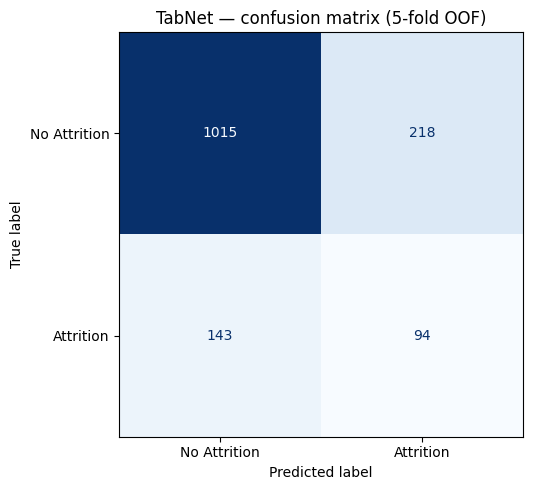

TabNet — classification report:
              precision    recall  f1-score   support

No Attrition       0.88      0.82      0.85      1233
   Attrition       0.30      0.40      0.34       237

    accuracy                           0.75      1470
   macro avg       0.59      0.61      0.60      1470
weighted avg       0.78      0.75      0.77      1470



In [39]:
# TabNet predictions already stored using each fold's own tuned threshold
show_confusion_and_report(tabnet_oof_true, tabnet_oof_pred, 'TabNet')

### V.3 LightGBM — Confusion Matrix & Report

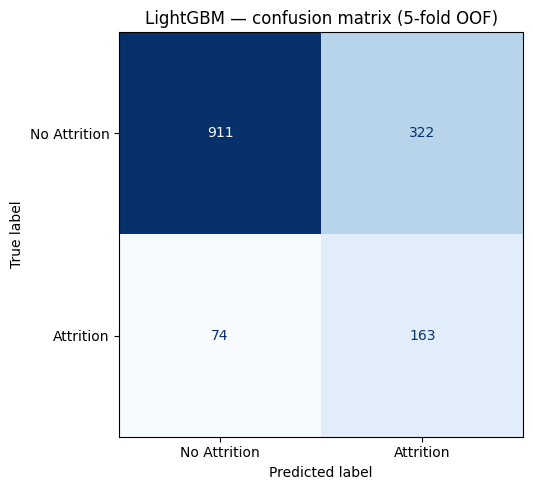

LightGBM — classification report:
              precision    recall  f1-score   support

No Attrition       0.92      0.74      0.82      1233
   Attrition       0.34      0.69      0.45       237

    accuracy                           0.73      1470
   macro avg       0.63      0.71      0.64      1470
weighted avg       0.83      0.73      0.76      1470



In [40]:
# LightGBM predictions already stored using each fold's own tuned threshold
show_confusion_and_report(lgbm_oof_true, lgbm_oof_pred, 'LightGBM')

### V.4 Hybrid — Confusion Matrix & Report

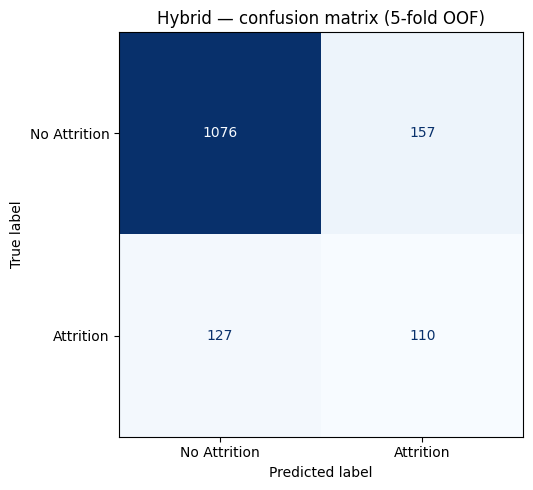

Hybrid — classification report:
              precision    recall  f1-score   support

No Attrition       0.89      0.87      0.88      1233
   Attrition       0.41      0.46      0.44       237

    accuracy                           0.81      1470
   macro avg       0.65      0.67      0.66      1470
weighted avg       0.82      0.81      0.81      1470



In [41]:
# hybrid predictions were already thresholded during CV, reuse as-is
show_confusion_and_report(hybrid_oof_true, hybrid_oof_pred, 'Hybrid')

### V.5 ROC Curve — Function

In [42]:
def plot_roc(ax, y_true, y_prob, label, color):
    # draws one ROC curve on a given axis, returns the AUC score
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, label=f'{label} (AUC={auc:.3f})', color=color, linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)  # chance-level diagonal
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    ax.legend()
    return auc

### V.6 ROC Curves — Individual per Model

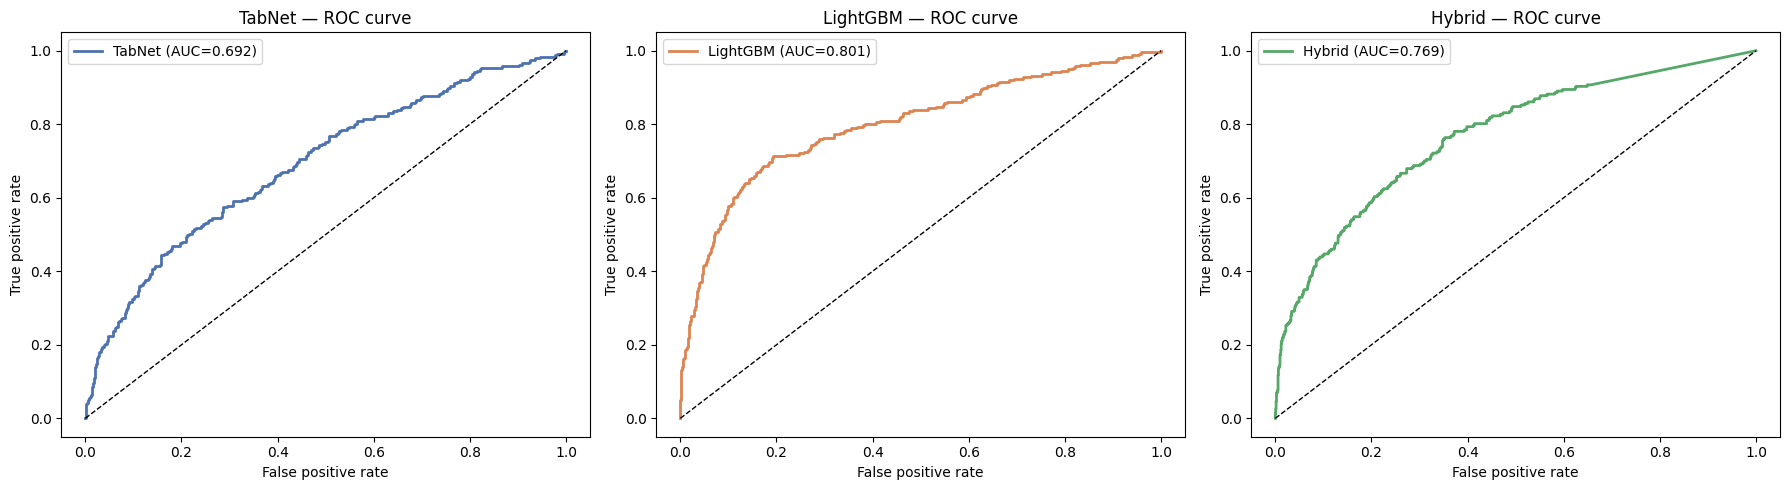

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_curves = [
    (tabnet_oof_true, tabnet_oof_prob, 'TabNet', '#4C72B0'),
    (lgbm_oof_true, lgbm_oof_prob, 'LightGBM', '#DD8452'),
    (hybrid_oof_true, hybrid_oof_prob, 'Hybrid', '#55A868'),
]
for ax, (y_true, y_prob, label, color) in zip(axes, model_curves):
    plot_roc(ax, y_true, y_prob, label, color)
    ax.set_title(f'{label} — ROC curve')

plt.tight_layout()
plt.show()

### V.7 ROC Curves — Combined Overlay

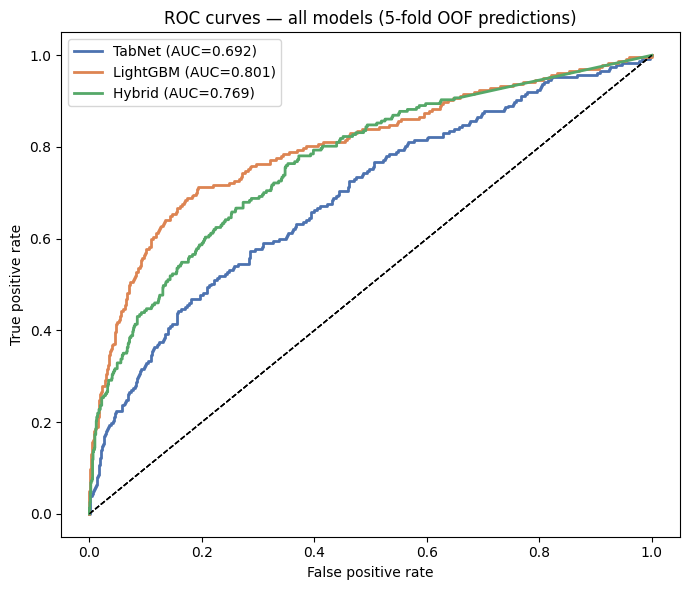

In [44]:
fig, ax = plt.subplots(figsize=(7, 6))
for y_true, y_prob, label, color in model_curves:
    plot_roc(ax, y_true, y_prob, label, color)  # one curve per model, same axis

ax.set_title('ROC curves — all models (5-fold OOF predictions)')
plt.tight_layout()
plt.show()

## VI. Model Comparison

### VI.1 Comparison Table

In [45]:
metrics_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']  # metrics shown in the table

rows = []
for name, summary in [('TabNet', tabnet_summary), ('LightGBM', lgbm_summary),
                       ('Hybrid', hybrid_summary)]:
    row = {'Model': name}
    for m in metrics_names:
        row[m.upper()] = f"{summary.loc['mean', m]:.4f} +/- {summary.loc['std', m]:.4f}"  # mean +/- std
    rows.append(row)

comparison_df = pd.DataFrame(rows).set_index('Model')
print(comparison_df.to_string())

                   ACCURACY          PRECISION             RECALL                 F1            ROC_AUC
Model                                                                                                  
TabNet    0.7544 +/- 0.1117  0.3653 +/- 0.0976  0.3957 +/- 0.2603  0.3201 +/- 0.0875  0.7162 +/- 0.0217
LightGBM  0.7306 +/- 0.0962  0.3666 +/- 0.0909  0.6870 +/- 0.1682  0.4571 +/- 0.0548  0.7998 +/- 0.0149
Hybrid    0.8068 +/- 0.0408  0.4295 +/- 0.0879  0.4641 +/- 0.0765  0.4387 +/- 0.0541  0.7700 +/- 0.0353


### VI.2 Bar Chart Comparison

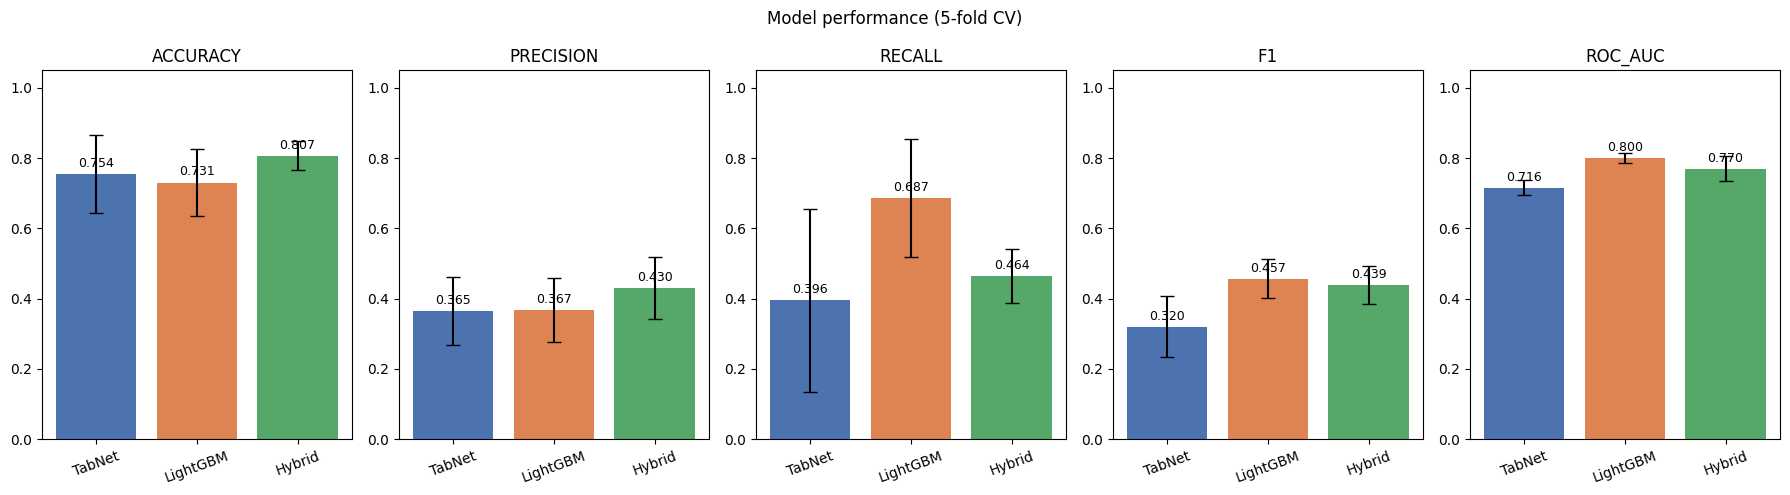

In [46]:
models = ['TabNet', 'LightGBM', 'Hybrid']
summaries = [tabnet_summary, lgbm_summary, hybrid_summary]
colors = ['#4C72B0', '#DD8452', '#55A868']  # consistent color per model

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for idx, metric in enumerate(metrics_names):
    means = [s.loc['mean', metric] for s in summaries]
    stds = [s.loc['std', metric] for s in summaries]
    bars = axes[idx].bar(models, means, yerr=stds, capsize=5, color=colors)  # bar + error bar
    axes[idx].set_title(metric.upper())
    axes[idx].set_ylim(0, 1.05)
    axes[idx].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, means):
        axes[idx].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                        f'{val:.3f}', ha='center', fontsize=9)  # value label above each bar

plt.suptitle('Model performance (5-fold CV)')
plt.tight_layout()
plt.show()

## VII. Interpretability

### VII.1 LightGBM Feature Importance

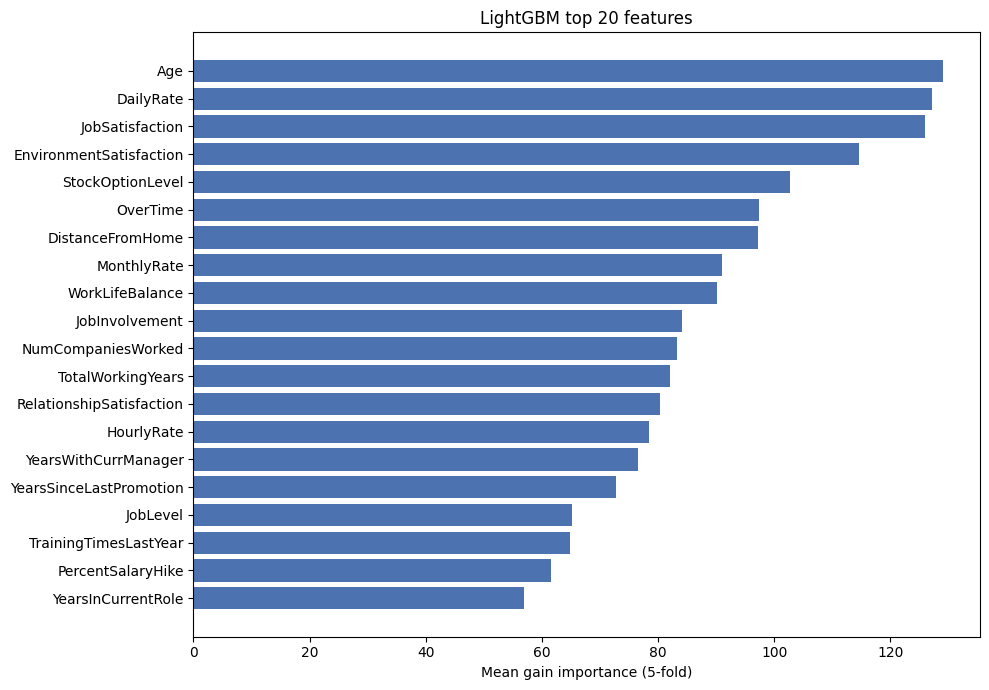

                Feature  Importance
                    Age       129.0
              DailyRate       127.2
        JobSatisfaction       126.0
EnvironmentSatisfaction       114.6
       StockOptionLevel       102.8
               OverTime        97.4
       DistanceFromHome        97.2
            MonthlyRate        91.0
        WorkLifeBalance        90.2
         JobInvolvement        84.2


In [47]:
mean_importance = np.mean(lgbm_feature_importances, axis=0)  # average across the 5 folds
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': mean_importance})
fi_df = fi_df.sort_values('Importance', ascending=False)

top_n = 20
fig, ax = plt.subplots(figsize=(10, 7))
top_fi = fi_df.head(top_n)
ax.barh(top_fi['Feature'][::-1], top_fi['Importance'][::-1], color='#4C72B0')  # reversed for descending top-to-bottom
ax.set_xlabel('Mean gain importance (5-fold)')
ax.set_title(f'LightGBM top {top_n} features')
plt.tight_layout()
plt.show()

print(fi_df.head(10).to_string(index=False))

### VII.2 TabNet Attention

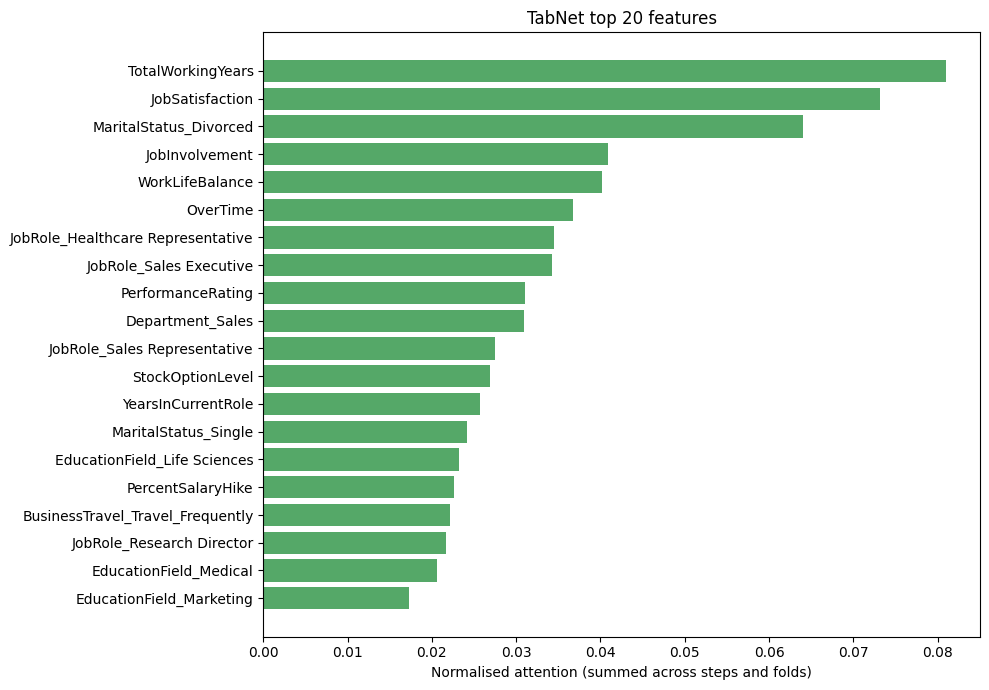

                          Feature  Attention
                TotalWorkingYears   0.080975
                  JobSatisfaction   0.073216
           MaritalStatus_Divorced   0.064027
                   JobInvolvement   0.040853
                  WorkLifeBalance   0.040202
                         OverTime   0.036773
JobRole_Healthcare Representative   0.034514
          JobRole_Sales Executive   0.034226
                PerformanceRating   0.031062
                 Department_Sales   0.030925


In [48]:
aggregated_attention = np.zeros(len(feature_names))
for fold_masks in tabnet_attention_masks:
    for step in fold_masks:
        aggregated_attention += fold_masks[step].sum(axis=0)  # sum attention across steps/folds
aggregated_attention /= aggregated_attention.sum()  # normalise to sum to 1

attention_df = pd.DataFrame({'Feature': feature_names, 'Attention': aggregated_attention})
attention_df = attention_df.sort_values('Attention', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
top_att = attention_df.head(top_n)
ax.barh(top_att['Feature'][::-1], top_att['Attention'][::-1], color='#55A868')  # reversed for descending top-to-bottom
ax.set_xlabel('Normalised attention (summed across steps and folds)')
ax.set_title(f'TabNet top {top_n} features')
plt.tight_layout()
plt.show()

print(attention_df.head(10).to_string(index=False))

### VII.3 Ethical Check — Demographic Proxies

In [49]:
# check that protected/sensitive attributes aren't dominating either model's decisions
demographic_proxies = ['Age', 'MaritalStatus_Single', 'MaritalStatus_Married',
                       'MaritalStatus_Divorced', 'Gender_Male', 'Gender_Female', 'Education']

print("LightGBM — rank of demographic proxies:")
for feat in demographic_proxies:
    match = fi_df[fi_df['Feature'] == feat]
    if len(match):
        importance = match['Importance'].values[0]
        rank = (fi_df['Importance'] >= importance).sum()  # rank among all features
        print(f"  {feat}: importance={importance:.2f} rank=#{rank}/{len(fi_df)}")

print("\nTabNet — attention rank of demographic proxies:")
for feat in demographic_proxies:
    match = attention_df[attention_df['Feature'] == feat]
    if len(match):
        score = match['Attention'].values[0]
        rank = (attention_df['Attention'] >= score).sum()  # rank among all features
        print(f"  {feat}: attention={score:.6f} rank=#{rank}/{len(attention_df)}")

LightGBM — rank of demographic proxies:
  Age: importance=129.00 rank=#1/48
  MaritalStatus_Single: importance=31.60 rank=#25/48
  MaritalStatus_Married: importance=15.60 rank=#32/48
  MaritalStatus_Divorced: importance=13.20 rank=#35/48
  Education: importance=47.20 rank=#22/48

TabNet — attention rank of demographic proxies:
  Age: attention=0.017256 rank=#22/48
  MaritalStatus_Single: attention=0.024148 rank=#14/48
  MaritalStatus_Married: attention=0.009077 rank=#37/48
  MaritalStatus_Divorced: attention=0.064027 rank=#3/48
  Education: attention=0.012538 rank=#30/48
